# FIE463 – Numerical Methods in Macroeconomics and Finance  
## Term Paper 2

---
<div style="margin-top: 30px;">

**Candidate numbers:** XXX  
Norwegian School of Economics (NHH)

</div>
---

<div style="margin-top: 40px; font-size: 14px; color: gray;">
Artificial intelligence tools (ChatGPT, openAI) have been used for support in this assignment. The tool has been used for code clarification, debugging, and improving language and structure. All analysis, implementation, and final solutions are our own work.
</div>

# Part 1 — Data preprocessing (SCE)

## Importing packages

In [52]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV

## 1. Import and merge SCE data
Loading all files and combine them into a single dataset

In [2]:
files = glob.glob("data/sce_extract_*.csv")

df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)

print(f"Total observations: {len(df)}")

Total observations: 180268


## 2. Forward fill variables

Some variables are only observed in the first survey wave, we therefpre forward-fill these variables within individuals 

In [3]:
df = df.sort_values(["userid", "date"])

#only filling individual characteristics
cols_to_fill = [
    "age_init", "female", "educ", "hh_inc_bin",
    "num_kids", "owner"
] 

df[cols_to_fill] = df.groupby("userid")[cols_to_fill].ffill()

## 3. Drop observations from 2025

We exclude observations from 2025 to avoid the volatility generated by the second Trump administration

In [4]:
# converting date to datetime
df["date"] = pd.to_datetime(df["date"])

before = len(df)

df = df[df["date"] < "2025-01-01"]

print(f"Dropped {before - len(df)} observations")

Dropped 4167 observations


## 4. Drop missing values

We remove observations with missing values for the selected variables

In [5]:
variables = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up"
]

before = len(df)

df = df.dropna(subset=variables)

print(f"Dropped {before - len(df)} observations (missing values)")

Dropped 1777 observations (missing values)


## 5. Removing outliers

Winsorizing extreme values by keeping observations between the 1st and 99th percentiles

In [6]:
mask = pd.Series(True, index=df.index)

for var in variables:
    p1 = df[var].quantile(0.01)
    p99 = df[var].quantile(0.99)
    
    mask &= (df[var] > p1) & (df[var] < p99)

df = df[mask]

## 6. Creating indicator variables

Constructing binary indicators capturing optimism about unemployment, stocks, and house prices

In [7]:
df["optimist_unrate"] = (df["prob_unrate_up"] < 50).astype(int)
df["optimist_stocks"] = (df["prob_stocks_up"] > 50).astype(int)
df["optimist_house_price"] = (df["house_price_change"] > 0).astype(int)

## 7. Summary statistics

Reporting the key dataset characteristics after cleaning 

In [8]:
print(f"Number of observations: {len(df)}")
print(f"Number of waves: {df['wid'].nunique()}")
print(f"First date: {df['date'].min()}")
print(f"Last date: {df['date'].max()}")

Number of observations: 159630
Number of waves: 139
First date: 2013-06-01 00:00:00
Last date: 2024-12-31 00:00:00


# Part 2 — Data preprocessing (macro/finance)

In the second part, we augment the SCE dataset with macroeconomic and financial tdata from Yahoo Finance and FRED. To avoid look-ahead bias, we ensure that only information available at the time of each survey is used when merging the data. We then construct additional variables capturing changes in the data (e.g., monthly differences).


Note: the data from Yahoo finance was downloaded using the yfinance package

## Choice of macroeconomic variables

We include a set of macroeconomic and financial variables that capture key drivers of household expectations across financial markets, inflation, and the real economy.

The S&P 500 and oil prices proxy for financial conditions and input cost shocks, while CPI and the unemployment rate capture inflation and labor market conditions that are directly relevant for households. The federal funds rate and mortgage rate reflect monetary policy and borrowing conditions, which influence both economic activity and housing expectations.

These variables are chosen as they are widely recognized, high-frequency indicators with clear economic interpretation and direct relevance for household beliefs, unlike more complex or less observable measures. All variables are included in lagged form to ensure that only information available at the time of the survey is used, thereby avoiding look-ahead bias.

## Loading macroeconomi and financial data

In [9]:
# Yahoo (skipping two rows)
sp500 = pd.read_csv("data/sp500.csv")
oil   = pd.read_csv("data/oil.csv")

# FRED 
cpi       = pd.read_csv("data/cpi.csv")
unrate    = pd.read_csv("data/unrate.csv")
fedfunds  = pd.read_csv("data/fedfunds.csv")
mortgage  = pd.read_csv("data/mortgage.csv")

## Cleaning Yahoo and FRED data

Yahoo Finance data contains extra header rows that we remove and FRED data is cleaned by renaming columns for consistency. Removing spaces and standardize lowercase. We then convert dates to datetime and then year-month, making us able to merge on month and not excact date. Also lagging the variables to ensure that only past information is usead to avoid look-ahead bias.

In [10]:
# cleaning yahoo
sp500 = sp500.iloc[:, [0, 4]]
oil   = oil.iloc[:, [0, 4]]

# remove first two rows (Ticker, Date)
sp500 = sp500.iloc[2:]
oil   = oil.iloc[2:]

# rename columns
sp500.columns = ["date", "sp500"]
oil.columns   = ["date", "oil"]

In [11]:
# cleaning FRED standardising and format the names
cpi = cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})

unrate = unrate.rename(columns={
    "observation_date": "date",
    "UNRATE": "unrate"
})

fedfunds = fedfunds.rename(columns={
    "observation_date": "date",
    "FEDFUNDS": "fedfunds"
})

mortgage = mortgage.rename(columns={
    "observation_date": "date",
    "MORTGAGE30US": "mortgage"
})

In [12]:
# datetime
for d in [sp500, oil, cpi, unrate, fedfunds, mortgage]:
    d["date"] = pd.to_datetime(d["date"])

In [20]:
# aggregate yahoo data to monthly
sp500 = sp500.sort_values("date")
oil   = oil.sort_values("date")

# convert to monthly, last observation in month
sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
oil   = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()

/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_29205/321765930.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_29205/321765930.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  oil   = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()


In [24]:
# FIX: ensure oil has full monthly coverage

# create full monthly index
full_index = pd.period_range(
    start=oil["year_month"].min(),
    end=oil["year_month"].max(),
    freq="M"
)

# reindex
oil = oil.set_index("year_month").reindex(full_index)

oil.index.name = "year_month"
oil = oil.reset_index()

# forward fill missing values
oil["oil"] = oil["oil"].ffill()

In [25]:
# monthly aligning
for d in [df, sp500, oil, cpi, unrate, fedfunds, mortgage]:
    d["year_month"] = d["date"].dt.to_period("M")

In [26]:
# creating lagged variables
sp500["sp500_lag"] = sp500["sp500"].shift(1)
oil["oil_lag"] = oil["oil"].shift(1)
cpi["cpi_lag"] = cpi["cpi"].shift(1)
unrate["unrate_lag"] = unrate["unrate"].shift(1)
fedfunds["fedfunds_lag"] = fedfunds["fedfunds"].shift(1)
mortgage["mortgage_lag"] = mortgage["mortgage"].shift(1)

In [27]:
# prepare SCE data
df["date"] = pd.to_datetime(df["date"])
df["year_month"] = df["date"].dt.to_period("M")

In [28]:
# merge data
df = df.merge(sp500[["year_month", "sp500_lag"]], on="year_month", how="left")
df = df.merge(oil[["year_month", "oil_lag"]], on="year_month", how="left")
df = df.merge(cpi[["year_month", "cpi_lag"]], on="year_month", how="left")
df = df.merge(unrate[["year_month", "unrate_lag"]], on="year_month", how="left")
df = df.merge(fedfunds[["year_month", "fedfunds_lag"]], on="year_month", how="left")
df = df.merge(mortgage[["year_month", "mortgage_lag"]], on="year_month", how="left")

# check
df.isna().sum()

userid              0
wid                 0
tenure              0
weight            873
date                0
                 ... 
oil_lag_y           0
cpi_lag_y           0
unrate_lag_y        0
fedfunds_lag_y      0
mortgage_lag_y      0
Length: 89, dtype: int64

After merging the macroeconomic variables with the SCE data using the monthly identifier, the data aligns well across all variables. 

There are no missing values in the macroeconomic variables after merging. The only missing values are in the weight variable, which originates from the SCE dataset and is unrelated to the macro data construction.

# Part 3 - Exploratory data analysis (SCE)

In the third part, we look at the  distribution and time evolution of  expectation variables in the SCE data. We visualize their distributions using histograms and examine how their average values and the share of optimistic households evolve over time.

## 1. Distribution of expectations

We begin by examining the distribution of responses for each expectations variable

In [31]:
# variables of interest
variables = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

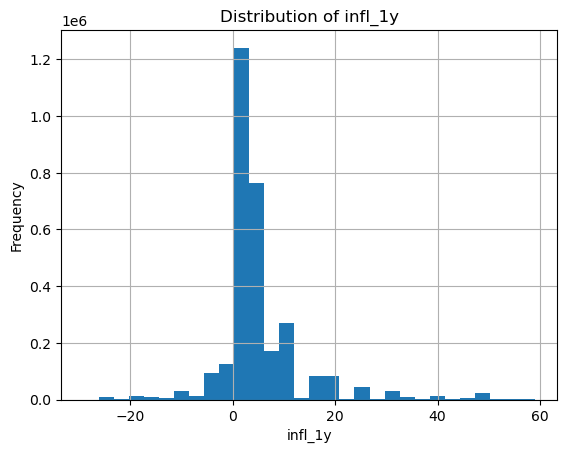

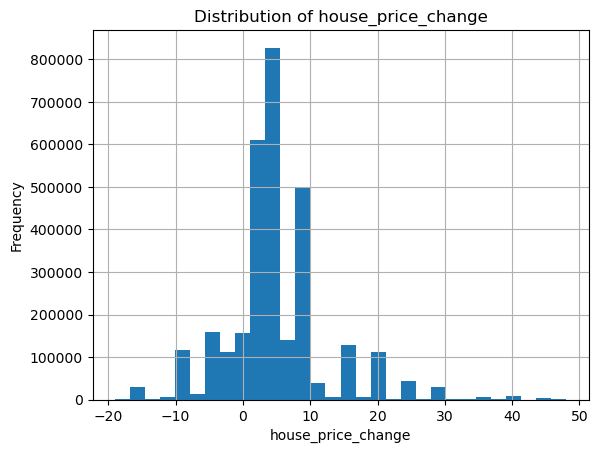

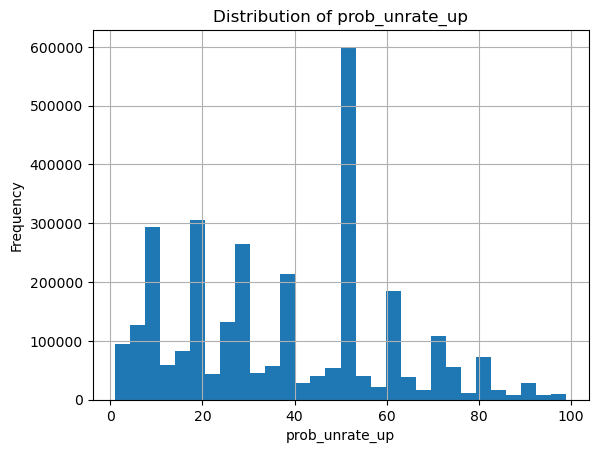

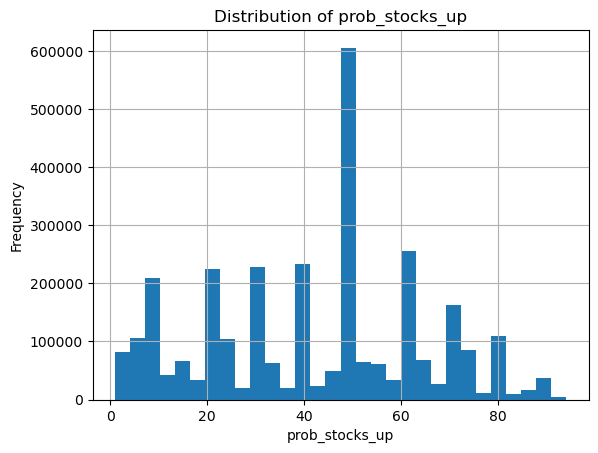

In [34]:
for var in variables:
    plt.figure()
    df[var].hist(bins=30)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

The histograms show that inflation expectations (infl_1y) are concentrated around low values but are right-skewed, with some extreme observations. House price expectations (house_price_change) are more centered around positive values, indicating that most households expect price increases.

The probability variables (prob_unrate_up and prob_stocks_up) are distributed between 0 and 100, with a clear concentration around 50. This suggests that many respondents are uncertain about future developments. The spikes at certain values likely reflect rounding in survey responses.

## 2. Average expectations over time

We examine how the average expectations evolve over time

In [35]:
# group by month and take mean
df_grouped = df.groupby("year_month")[variables].mean()

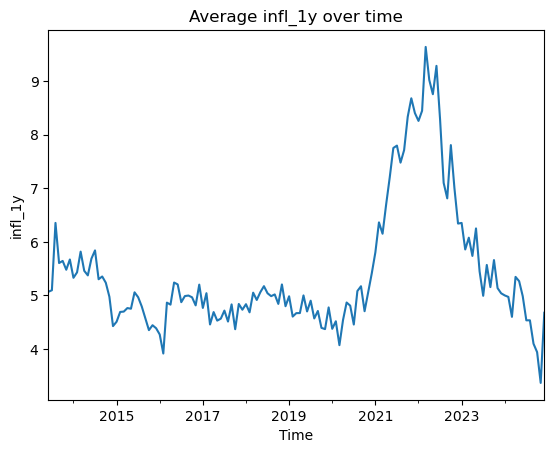

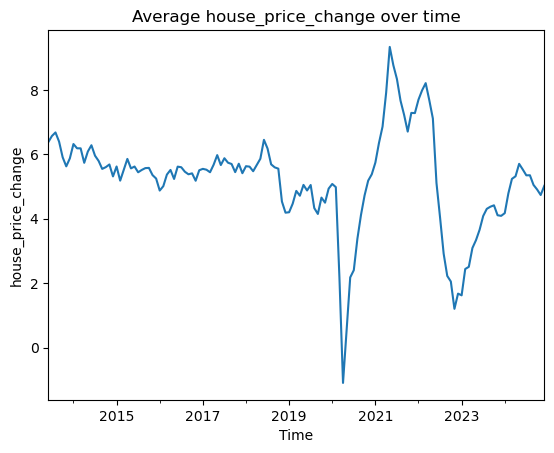

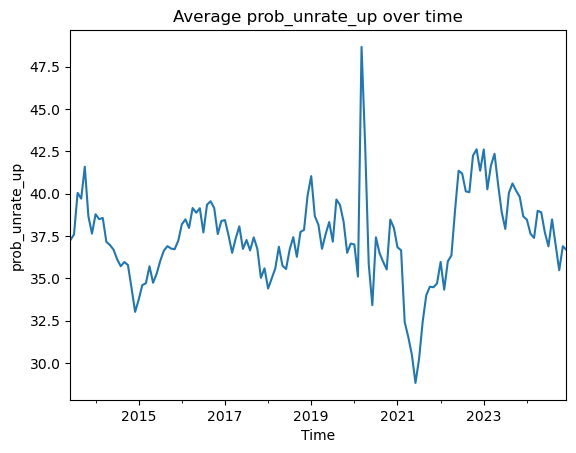

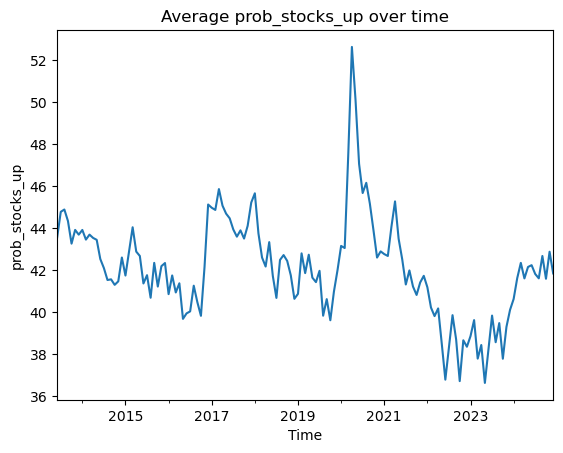

In [36]:
for var in variables:
    plt.figure()
    df_grouped[var].plot()
    plt.title(f"Average {var} over time")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.show()

The time series show that inflation expectations (infl_1y) were relatively stable before increasing sharply around 2021–2022, followed by a decline. This likely reflects changing macroeconomic conditions during this period.

House price expectations (house_price_change) display more volatility, with a strong drop around 2020 and a sharp increase afterward, before stabilizing again.

The probability of higher unemployment (prob_unrate_up) fluctuates over time, with noticeable spikes during periods of economic uncertainty, suggesting that households adjust expectations in response to shocks.

Similarly, expectations about stock market increases (prob_stocks_up) vary over time, with a clear peak around 2020–2021 and a decline afterward, indicating changing sentiment in financial markets.

## Share of optimistic households

We examine the share of households classified as optimistic

In [37]:
# grouping by month and calculating mean for the two selected variables
optimist_vars = ["optimist_unrate", "optimist_stocks"]

df_opt = df.groupby("year_month")[optimist_vars].mean()

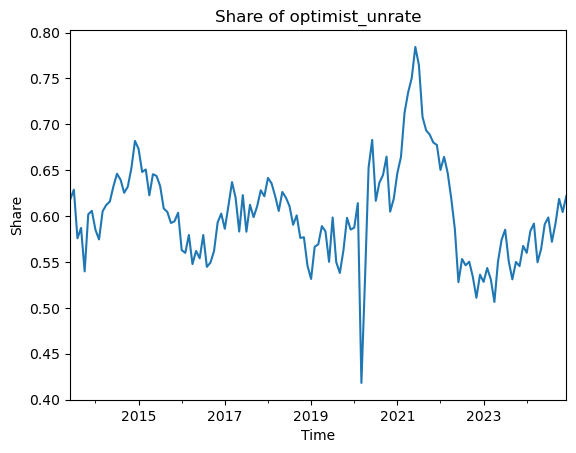

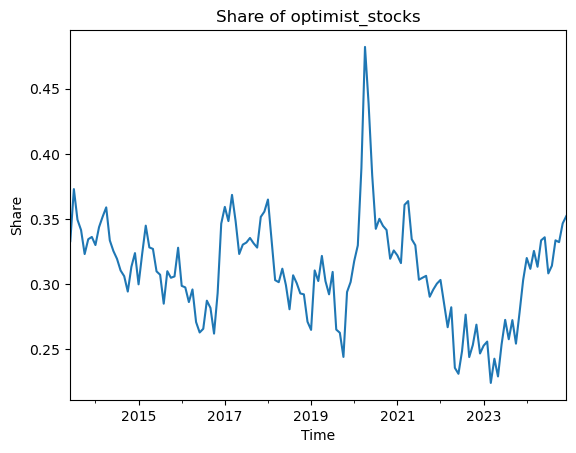

In [38]:
# plot
for var in optimist_vars:
    plt.figure()
    df_opt[var].plot()
    plt.title(f"Share of {var}")
    plt.xlabel("Time")
    plt.ylabel("Share")
    plt.show()

The share of optimistic households fluctuates over time, with a clear peak around 2020–2021. This pattern indicates that expectations are sensitive to macroeconomic developments.

Both series show similar dynamics, suggesting that optimism about labor markets and financial markets tends to move together over time.

# Task 4 - Exploratory data analysis (macro/finance)

In task 4 we examine how macroeconomic variables help explain household expectations. Again, we use lagged macro variables to avoid look ahead bias

## 1. Figure showing the time series of the original variables in levels

In [40]:
# Creating change variables
sp500["sp500_change"] = sp500["sp500"].diff()
oil["oil_change"] = oil["oil"].diff()
cpi["cpi_change"] = cpi["cpi"].diff()
unrate["unrate_change"] = unrate["unrate"].diff()
fedfunds["fedfunds_change"] = fedfunds["fedfunds"].diff()
mortgage["mortgage_change"] = mortgage["mortgage"].diff()

In [41]:
# merge changes into df
df = df.merge(sp500[["year_month", "sp500_change"]], on="year_month", how="left")
df = df.merge(oil[["year_month", "oil_change"]], on="year_month", how="left")
df = df.merge(cpi[["year_month", "cpi_change"]], on="year_month", how="left")
df = df.merge(unrate[["year_month", "unrate_change"]], on="year_month", how="left")
df = df.merge(fedfunds[["year_month", "fedfunds_change"]], on="year_month", how="left")
df = df.merge(mortgage[["year_month", "mortgage_change"]], on="year_month", how="left")

In [39]:
# restrict to SCE period
start = df["year_month"].min()
end = df["year_month"].max()

df_macro = df[(df["year_month"] >= start) & (df["year_month"] <= end)]

# 1. polotting varaible levels

In [42]:
# keep only one version of macro variables (use _x)
df_macro = df_macro.rename(columns={
    "sp500_lag_x": "sp500_lag",
    "oil_lag_x": "oil_lag",
    "cpi_lag_x": "cpi_lag",
    "unrate_lag_x": "unrate_lag",
    "fedfunds_lag_x": "fedfunds_lag",
    "mortgage_lag_x": "mortgage_lag"
})

# drop the duplicate _y columns
df_macro = df_macro.drop(columns=[
    "sp500_lag_y",
    "oil_lag_y",
    "cpi_lag_y",
    "unrate_lag_y",
    "fedfunds_lag_y",
    "mortgage_lag_y"
])

<Figure size 640x480 with 0 Axes>

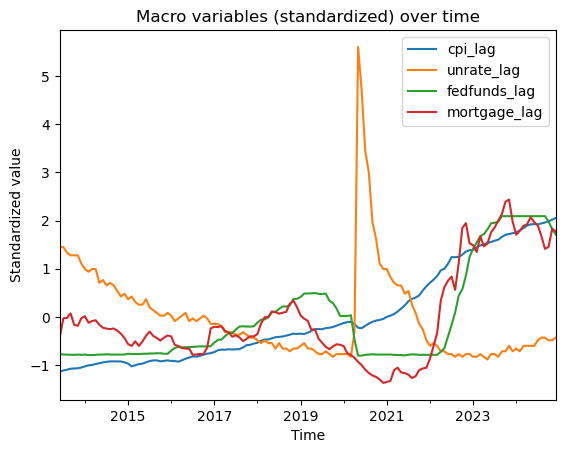

In [44]:
macro_vars = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]

df_levels = df_macro.groupby("year_month")[macro_vars].mean(numeric_only=True)

# Standardize for better comparison (important fix)
df_levels_std = (df_levels - df_levels.mean()) / df_levels.std()

plt.figure()
df_levels_std.plot()
plt.title("Macro variables (standardized) over time")
plt.xlabel("Time")
plt.ylabel("Standardized value")
plt.show()

The standardized level plot shows the evolution of macroeconomic variables over time while allowing for better comparison across series with different scales. The S&P 500 exhibits a strong upward trend, while variables such as inflation, unemployment, and interest rates remain relatively stable. Standardization makes it easier to compare movements across variables that would otherwise differ significantly in magnitude.

# 2.plot changes in macro variables

<Figure size 640x480 with 0 Axes>

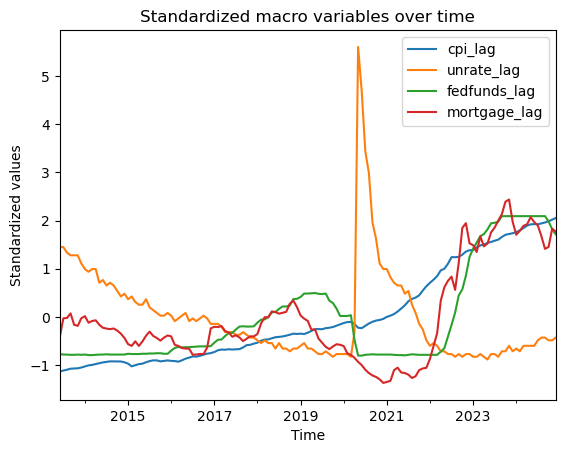

In [50]:
macro_changes = [
    "sp500_lag",
    "oil_lag",
    "cpi_lag",
    "unrate_lag",
    "fedfunds_lag",
    "mortgage_lag"
]

df_changes_std = (df_changes - df_changes.mean()) / df_changes.std()

plt.figure()
df_changes_std.plot()
plt.title("Standardized macro variables over time")
plt.xlabel("Time")
plt.ylabel("Standardized values")
plt.show()

The standardized plot shows that macro variables move differently over time. Inflation (CPI) follows a steady upward trend, while interest rates (fed funds and mortgage rates) increase sharply after 2021. Unemployment exhibits a large temporary spike around 2020, reflecting a short-lived shock. Overall, financial variables appear more volatile than inflation.

# 3. correlation between macro vraiables and expections variables

In [51]:
expectation_vars = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

macro_all = macro_vars + macro_changes

for var in expectation_vars:
    corr = df_macro[macro_all + [var]].corr()[var].drop(var)    
    corr = corr.sort_values(ascending=False)

    print(f"\nCorrelation with {var}:")
    print(corr.round(3))


Correlation with infl_1y:
oil_lag         0.065
oil_lag         0.065
sp500_lag       0.057
sp500_lag       0.057
cpi_lag         0.046
cpi_lag         0.046
mortgage_lag   -0.001
mortgage_lag   -0.001
unrate_lag     -0.009
unrate_lag     -0.009
fedfunds_lag   -0.025
fedfunds_lag   -0.025
Name: infl_1y, dtype: float64

Correlation with house_price_change:
oil_lag         0.023
oil_lag         0.023
unrate_lag      0.005
unrate_lag      0.005
sp500_lag      -0.015
sp500_lag      -0.015
cpi_lag        -0.054
cpi_lag        -0.054
mortgage_lag   -0.073
mortgage_lag   -0.073
fedfunds_lag   -0.082
fedfunds_lag   -0.082
Name: house_price_change, dtype: float64

Correlation with prob_unrate_up:
mortgage_lag    0.054
mortgage_lag    0.054
fedfunds_lag    0.044
fedfunds_lag    0.044
cpi_lag         0.025
cpi_lag         0.025
oil_lag         0.018
oil_lag         0.018
sp500_lag      -0.001
sp500_lag      -0.001
unrate_lag     -0.030
unrate_lag     -0.030
Name: prob_unrate_up, dtype: float64



The correlations between macro variables and expectations are generally very small, suggesting limited explanatory power. 

A few weak patterns emerge: inflation expectations (infl_1y) are slightly positively correlated with oil prices and stock market levels, while house price expectations are weakly negatively related to interest rates (fed funds and mortgage rates). Overall, the results indicate that individual expectations are only weakly related to aggregate macroeconomic conditions

# Part 5 - Predicting continuous expectation variables

We split the data into a training sample (before 2024) and a test sample (2024). Thereafter, estimate Linear Regression, Ridge, and Lasso models using macroeconomic variables. The models are then extanded to include individual variables.  

## 1. Split data

In [55]:
df["date"] = pd.to_datetime(df["date"])

df_train = df[df["date"] < "2024-01-01"]
df_test  = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]

## 2. Define varaibles

In [59]:
X_macro = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]
X_extra = ["age_init", "educ", "hh_inc_bin", "female"]

## Macro variables


In [60]:
(df["sp500_lag_x"] - df["sp500_lag_y"]).describe()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [57]:
# prepare data
y_var = "infl_1y"
X_vars = X_macro

train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_vars + [y_var, "year_month"]].dropna().copy()

X_train = train[X_vars]
y_train = train[y_var]

X_test = test[X_vars]
y_test = test[y_var]

KeyError: "['sp500_lag', 'oil_lag', 'cpi_lag', 'unrate_lag', 'fedfunds_lag', 'mortgage_lag'] not in index"

# Gammel kode

In [ ]:
# importing Train-test split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV


In [ ]:
# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Split
df_train = df[df["date"] < "2024-01-01"]
df_test  = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]

#  Define variables

we define target, arco and individual vraiables

In [62]:
# Target variable (start with one)
y_var = "infl_1y"

# Macro variables
X_macro = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]

# Individual variables (chosen subset)
X_extra = ["age_init", "educ", "hh_inc_bin", "female"]

# Part 1: Macro models

In [63]:
X_vars = X_macro

train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_vars + [y_var, "year_month"]].dropna().copy()

X_train = train[X_vars]
y_train = train[y_var]

X_test = test[X_vars]
y_test = test[y_var]

In [64]:
# Linear Regression (no hyperparameters, no scaling needed)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 9.141105357434496
R2: -0.03401190329593007


# Ridge regression

In [65]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

alphas = np.logspace(-3, 3, 20)

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

print("Best alpha:", ridge.named_steps["model"].alpha_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Best alpha: 1000.0
RMSE: 9.141174516464712
R2: -0.03402754944115749


## Rigid validation curve

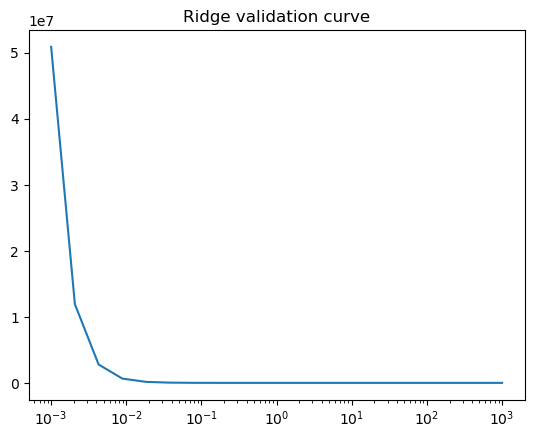

In [66]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt

train_scores, val_scores = validation_curve(
    RidgeCV(),
    X_train, y_train,
    param_name="alphas",
    param_range=alphas,
    scoring="neg_mean_squared_error",
    cv=5
)

plt.figure()
plt.plot(alphas, -val_scores.mean(axis=1))
plt.xscale("log")
plt.title("Ridge validation curve")
plt.show()

## Lasso regression

In [67]:
from sklearn.linear_model import LassoCV

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5))
])

lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

print("Best alpha:", lasso.named_steps["model"].alpha_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Best alpha: 0.006355123700408093
RMSE: 9.142988418268313
R2: -0.03443795852491549


<Figure size 640x480 with 0 Axes>

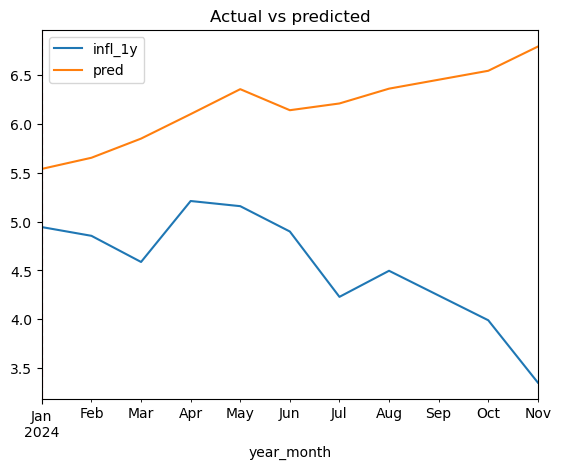

In [68]:
# plot
test["pred"] = y_pred

df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()

plt.figure()
df_plot.plot()
plt.axvline(x="2024-01", color="red", linestyle="--")
plt.title("Actual vs predicted")
plt.show()

## Part b: Individual code

In [69]:
# New features
X_vars = X_macro + X_extra

train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_vars + [y_var, "year_month"]].dropna().copy()

X_train = train[X_vars]
y_train = train[y_var]

X_test = test[X_vars]
y_test = test[y_var]

In [70]:
# running ridge again
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 8.983716490252375
R2: 0.002681528230261798


<Figure size 640x480 with 0 Axes>

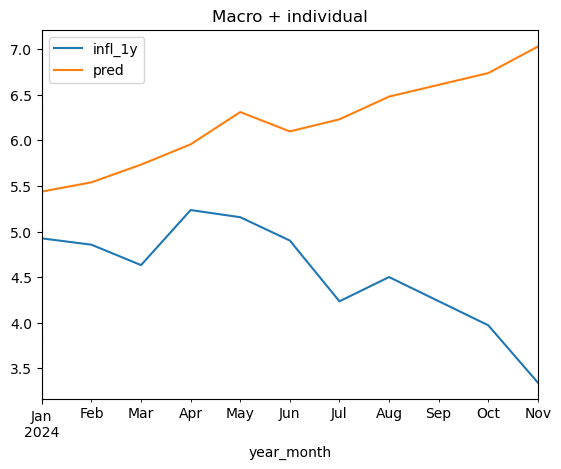

In [71]:
# plot again
test["pred"] = y_pred

df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()

plt.figure()
df_plot.plot()
plt.axvline(x="2024-01", color="red", linestyle="--")
plt.title("Macro + individual")
plt.show()

# Linear regression

Linear regression has no hyperparameters and does not require feature scaling.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression:")
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression:
RMSE: 9.141105357434496
R2: -0.03401190329593007


# Ridge regression
Ridge regression includes a penalty parameter (alpha) and requires feature scaling

In [49]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

alphas = np.logspace(-3, 3, 20)

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRidge Regression:")
print("Best alpha:", ridge.named_steps["model"].alpha_)
print("RMSE:", rmse)
print("R2:", r2)


Ridge Regression:
Best alpha: 1000.0
RMSE: 9.141174516464712
R2: -0.03402754944115749


# Validation curve

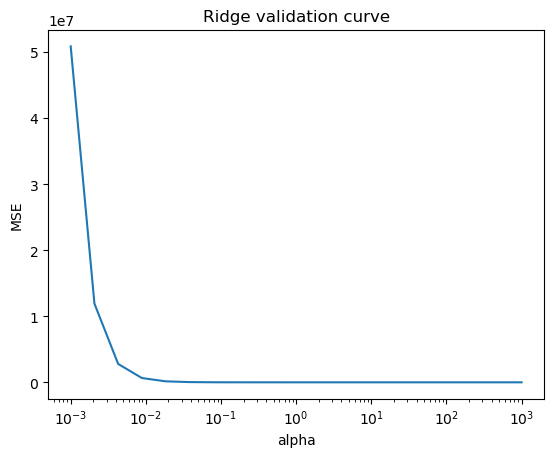

In [50]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt

train_scores, val_scores = validation_curve(
    RidgeCV(),
    X_train, y_train,
    param_name="alphas",
    param_range=alphas,
    scoring="neg_mean_squared_error",
    cv=5
)

plt.figure()
plt.plot(alphas, -val_scores.mean(axis=1))
plt.xscale("log")
plt.title("Ridge validation curve")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.show()

# Lasso regression

In [51]:
from sklearn.linear_model import LassoCV

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5))
])

lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nLasso Regression:")
print("Best alpha:", lasso.named_steps["model"].alpha_)
print("RMSE:", rmse)
print("R2:", r2)


Lasso Regression:
Best alpha: 0.006355123700408093
RMSE: 9.142988418268313
R2: -0.03443795852491549


# annual vs predicted

In [55]:
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

<Figure size 640x480 with 0 Axes>

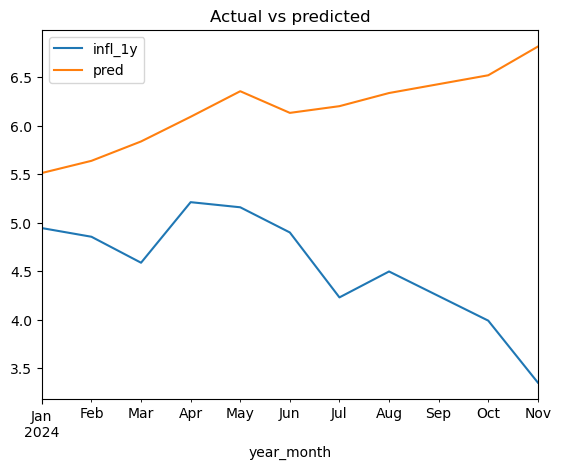

In [56]:
test["pred"] = y_pred

df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()

plt.figure()
df_plot.plot()
plt.title("Actual vs predicted")
plt.show()

# Part 6 - Predicting binary optimism variables

In this part, we predict binary optimism variables using classification models. We use logistic regression and random forest, and evaluate performance using accuracy metrics

## Defining variables

In [72]:
# Target variable (start with one)
y_var = "optimist_unrate"

# Features
X_macro = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]
X_extra = ["age_init", "educ", "hh_inc_bin", "female"]

## Part A - Macro only

In [73]:
# prepare data
train = df_train[X_macro + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_macro + [y_var, "year_month"]].dropna().copy()

X_train = train[X_macro]
y_train = train[y_var]

X_test = test[X_macro]
y_test = test[y_var]

In [74]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

logit = LogisticRegression(max_iter=1000)  # increase iterations to ensure convergence
logit.fit(X_train, y_train)

y_pred = logit.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5821325346625895
Confusion matrix:
 [[     0  79806]
 [     0 111178]]


In [75]:
# random forest (with CV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=0)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 3, 'n_estimators': 50}


In [76]:
# evaluate random forest
y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5821325346625895
Confusion matrix:
 [[     0  79806]
 [     0 111178]]


<Figure size 640x480 with 0 Axes>

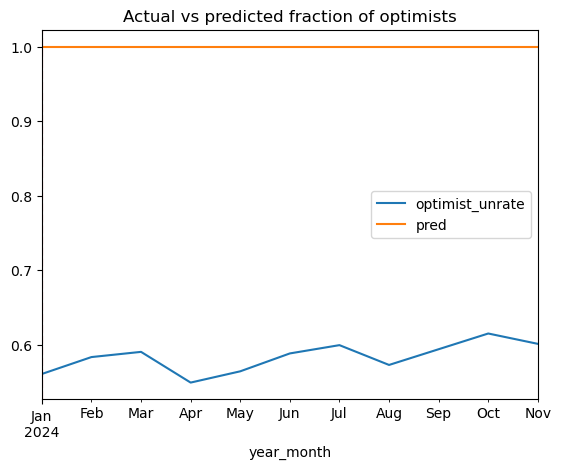

In [77]:
# plot fraction of optimists
test["pred"] = y_pred

df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()

import matplotlib.pyplot as plt

plt.figure()
df_plot.plot()
plt.axvline(x="2024-01", color="red", linestyle="--")  # train/test split
plt.title("Actual vs predicted fraction of optimists")
plt.show()

## Part B - add individual varaibles

In [78]:
# new features
X_vars = X_macro + X_extra

train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_vars + [y_var, "year_month"]].dropna().copy()

X_train = train[X_vars]
y_train = train[y_var]

X_test = test[X_vars]
y_test = test[y_var]

In [79]:
# running random forest again
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5822362851337622
Confusion matrix:
 [[   148  78913]
 [    41 109890]]


<Figure size 640x480 with 0 Axes>

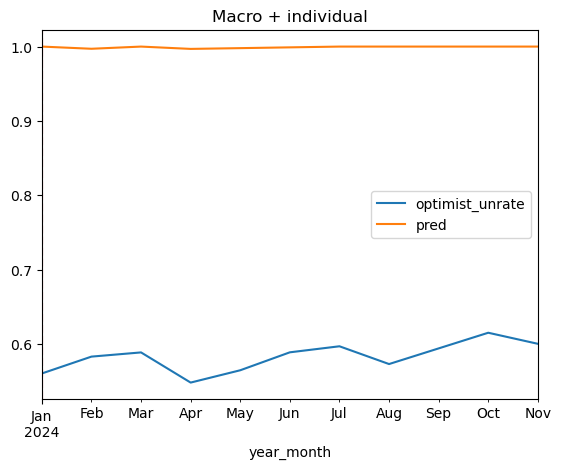

In [80]:
# plot again
test["pred"] = y_pred

df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()

plt.figure()
df_plot.plot()
plt.axvline(x="2024-01", color="red", linestyle="--")
plt.title("Macro + individual")
plt.show()

# Part 7 -  Conclusion